In [1]:
import pandas as pd
import datetime as dt

In [2]:
df_google_trends = pd.read_csv("data/google_trends_data.csv").set_index("date")
df_google_trends

,pédantix,pedantix,cémantix,cemantix
date,,,,
2022-01-13,0.0,0.0,0.0,0.0
2022-01-14,0.0,0.0,0.0,0.0
2022-01-15,0.0,0.0,0.0,0.0
2022-01-16,0.0,0.0,0.0,0.0
2022-01-17,0.0,0.0,0.0,0.0
...,...,...,...,...
2026-02-10,15.0,21.0,27.0,72.0
2026-02-11,14.0,20.0,30.0,96.0
2026-02-12,17.0,23.0,25.0,76.0


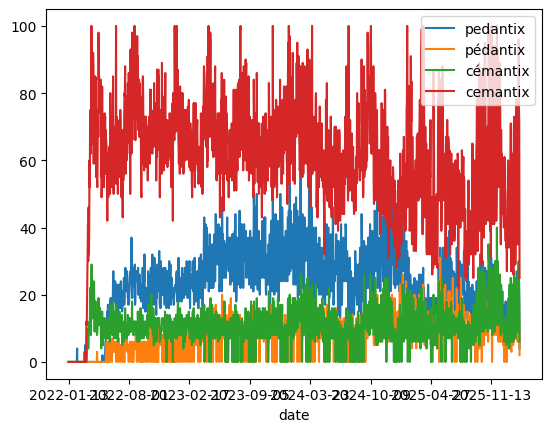

In [3]:
df_google_trends.plot(y=["pedantix", "pédantix", "cémantix", "cemantix"]);

In [4]:
df_winners = pd.read_csv('data/pedantix_data.txt', sep="\t", header = None)
df_winners.columns = ['Numéro', 'Solvers', 'Page']
today = dt.date(year = 2025, month = 12, day = 3)
today_nr = 1300
date_col = [today - dt.timedelta(1300 - number) for number in df_winners.Numéro]
df_winners['date'] = date_col
df_winners = df_winners.set_index("date")
df_winners

,Numéro,Solvers,Page
date,,,
2022-05-14,1,4398,Affaire Dreyfus
2022-05-15,2,6632,Nestlé
2022-05-16,3,9224,Formation et évolution du Système solaire
2022-05-17,4,13865,Strasbourg
2022-05-18,5,11130,Processeur
...,...,...,...
2025-11-04,1271,33282,Premier Empire bulgare
2025-11-05,1272,36303,Violon
2025-11-06,1273,38471,Fée


In [5]:
df_google_trends.index = pd.to_datetime(df_google_trends.index)
df_winners.index = pd.to_datetime(df_winners.index)

merged_inner = df_winners.join(df_google_trends, how="inner")
merged_inner = merged_inner.rename(columns={"Solvers":"winners", "Page":"page", "Numéro":"number"})
merged_inner

,number,winners,page,pédantix,pedantix,cémantix,cemantix
date,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0
...,...,...,...,...,...,...,...
2025-11-04,1271,33282,Premier Empire bulgare,16.0,23.0,31.0,95.0
2025-11-05,1272,36303,Violon,13.0,19.0,30.0,95.0
2025-11-06,1273,38471,Fée,16.0,24.0,27.0,90.0


In [6]:
merged_inner.to_csv("data/cleaned_data.csv")